In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both sheets and combine
df1 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

df = pd.concat([df1, df2], ignore_index=True)

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
# Check for cancelled orders, they start with 'C' in the Invoice column
cancelled = df[df['Invoice'].astype(str).str.startswith('C', na=False)]
print("Total cancelled transactions:", len(cancelled))
print("Cancelled as % of total:", round(len(cancelled)/len(df)*100, 2), "%")

# Also check negative quantities
negative_qty = df[df['Quantity'] < 0]
print("\nNegative quantity rows:", len(negative_qty))

# Quick look at what a cancellation looks like
cancelled.head(3)

Total cancelled transactions: 19494
Cancelled as % of total: 1.83 %

Negative quantity rows: 22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia


In [8]:
print("=" * 45)
print("DATA QUALITY REPORT")
print("=" * 45)

print(f"\nTotal rows: {len(df):,}")
print(f"\n--- NULLS ---")
print(f"Missing Customer ID : {df['Customer ID'].isna().sum():,} ({round(df['Customer ID'].isna().sum()/len(df)*100,1)}%)")
print(f"Missing Description : {df['Description'].isna().sum():,} ({round(df['Description'].isna().sum()/len(df)*100,1)}%)")

print(f"\n--- CANCELLATIONS ---")
print(f"Cancelled invoices  : {19494:,} (1.83%)")
print(f"Negative quantities : {22950:,} ({round(22950/len(df)*100,1)}%)")

print(f"\n--- DATA TYPES ---")
print(f"Customer ID stored as float (should be string)")
print(f"InvoiceDate already datetime ✓")

print(f"\n--- PRICE ISSUES ---")
print(f"Zero price rows     : {(df['Price'] == 0).sum():,}")
print(f"Negative price rows : {(df['Price'] < 0).sum():,}")

DATA QUALITY REPORT

Total rows: 1,067,371

--- NULLS ---
Missing Customer ID : 243,007 (22.8%)
Missing Description : 4,382 (0.4%)

--- CANCELLATIONS ---
Cancelled invoices  : 19,494 (1.83%)
Negative quantities : 22,950 (2.2%)

--- DATA TYPES ---
Customer ID stored as float (should be string)
InvoiceDate already datetime ✓

--- PRICE ISSUES ---
Zero price rows     : 6,202
Negative price rows : 5


In [9]:
print(f"Starting rows: {len(df):,}")

# Step 1 : Remove missing Customer IDs
df = df[df['Customer ID'].notna()]
print(f"After removing missing Customer ID: {len(df):,}")

# Step 2 : Remove missing Descriptions
df = df[df['Description'].notna()]
print(f"After removing missing Description: {len(df):,}")

# Step 3 : Remove cancellations (Invoice starting with C)
df = df[~df['Invoice'].astype(str).str.startswith('C', na=False)]
print(f"After removing cancellations: {len(df):,}")

# Step 4 : Remove negative and zero quantities
df = df[df['Quantity'] > 0]
print(f"After removing negative/zero quantities: {len(df):,}")

# Step 5 : Remove zero and negative prices
df = df[df['Price'] > 0]
print(f"After removing zero/negative prices: {len(df):,}")

# Step 6 : Fix Customer ID data type (12345.0 → "12345")
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

# Step 7 : Create a Revenue column (the most important derived column)
df['Revenue'] = df['Quantity'] * df['Price']

print(f"\nFinal clean rows: {len(df):,}")
print(f"Rows removed: {1067371 - len(df):,}")
print(f"Data retained: {round(len(df)/1067371*100, 1)}%")

Starting rows: 1,067,371
After removing missing Customer ID: 824,364
After removing missing Description: 824,364
After removing cancellations: 805,620
After removing negative/zero quantities: 805,620
After removing zero/negative prices: 805,549

Final clean rows: 805,549
Rows removed: 261,822
Data retained: 75.5%


In [10]:
# Verify the clean dataset looks correct
print("Clean Dataset Summary")
print("=" * 40)
print(f"Transactions     : {len(df):,}")
print(f"Unique customers : {df['Customer ID'].nunique():,}")
print(f"Unique products  : {df['StockCode'].nunique():,}")
print(f"Unique countries : {df['Country'].nunique():,}")
print(
    f"Date range       : {df['InvoiceDate'].min().strftime('%d-%m-%Y')} to "
    f"{df['InvoiceDate'].max().strftime('%d-%m-%Y')}"
)
print(f"Total revenue    : £{df['Revenue'].sum():,.2f}")
print(f"Avg order value  : £{df.groupby('Invoice')['Revenue'].sum().mean():,.2f}")

Clean Dataset Summary
Transactions     : 805,549
Unique customers : 5,878
Unique products  : 4,631
Unique countries : 41
Date range       : 01-12-2009 to 09-12-2011
Total revenue    : £17,743,429.18
Avg order value  : £479.95


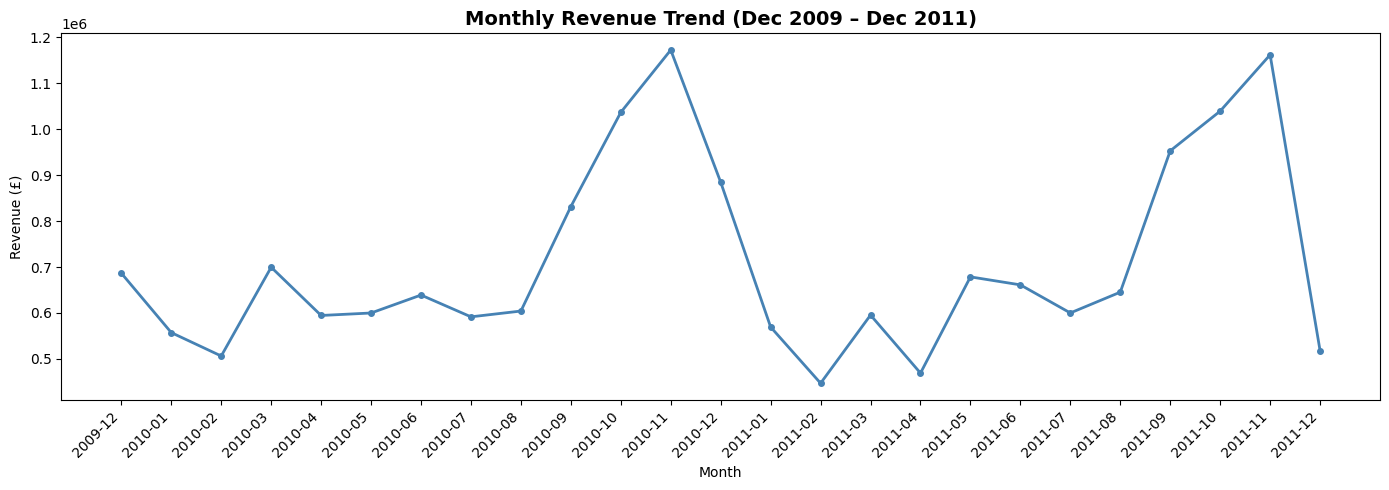


Top 3 Revenue Months:
YearMonth: Revenue:  
2010-11    1172336.04
2011-11    1161817.38
2011-10    1039318.79


In [33]:
# Extract year-month from InvoiceDate
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Group by month and sum revenue
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'], 
         marker='o', color='steelblue', linewidth=2, markersize=4)

plt.title('Monthly Revenue Trend (Dec 2009 – Dec 2011)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/monthly_revenue.png', dpi=150)
plt.show()

# Print top 3 months
top_months = monthly_revenue.sort_values('Revenue', ascending=False).head(3)
print("\nTop 3 Revenue Months:")
print(f"{'YearMonth'':':^10} {'Revenue:':<10}")

for _, row in top_months.iterrows():
    print(f"{row['YearMonth']:<10} {row['Revenue']:.2f}")

UK Revenue: £14,723,147.52
UK % of total: 83.0%


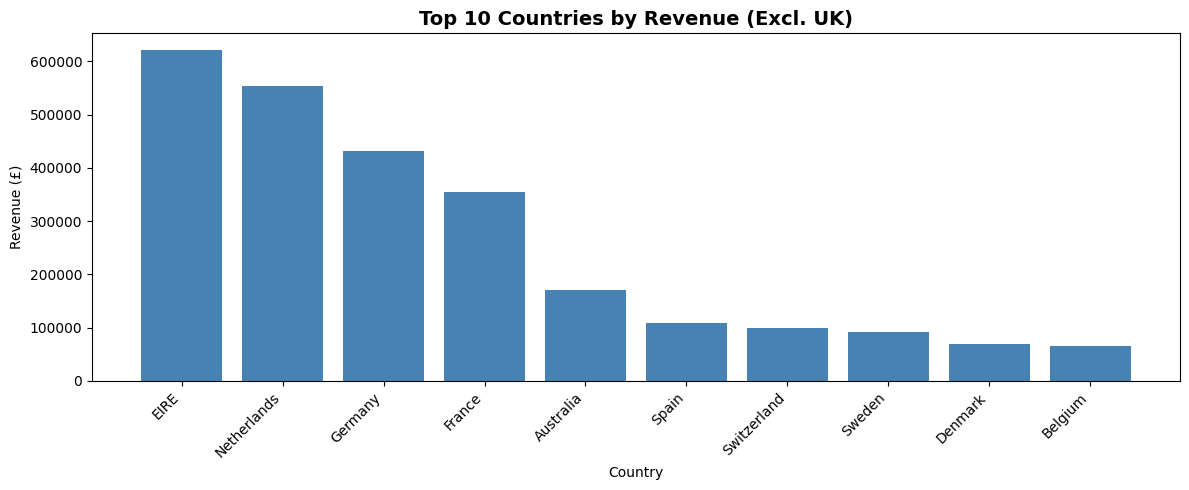


Top 10 Countries (excl. UK):
    Country   Revenue
       EIRE 621631.11
Netherlands 554232.34
    Germany 431262.46
     France 355257.47
  Australia 169968.11
      Spain 109178.53
Switzerland 100365.34
     Sweden  91549.72
    Denmark  69862.19
    Belgium  65753.42


In [34]:
# Excluding UK since it dominates, we'll show it separately
country_revenue = df.groupby('Country')['Revenue'].sum().round(2).reset_index()
country_revenue = country_revenue.sort_values('Revenue', ascending=False)

# Print UK separately
uk = country_revenue[country_revenue['Country'] == 'United Kingdom']
print(f"UK Revenue: £{uk['Revenue'].values[0]:,.2f}")
print(f"UK % of total: {round(uk['Revenue'].values[0]/df['Revenue'].sum()*100, 1)}%")

# Top 10 excluding UK
top_countries = country_revenue[country_revenue['Country'] != 'United Kingdom'].head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_countries['Country'], top_countries['Revenue'], color='steelblue')
plt.title('Top 10 Countries by Revenue (Excl. UK)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/top_countries.png', dpi=150)
plt.show()

print("\nTop 10 Countries (excl. UK):")
print(top_countries[['Country', 'Revenue']].to_string(index=False))

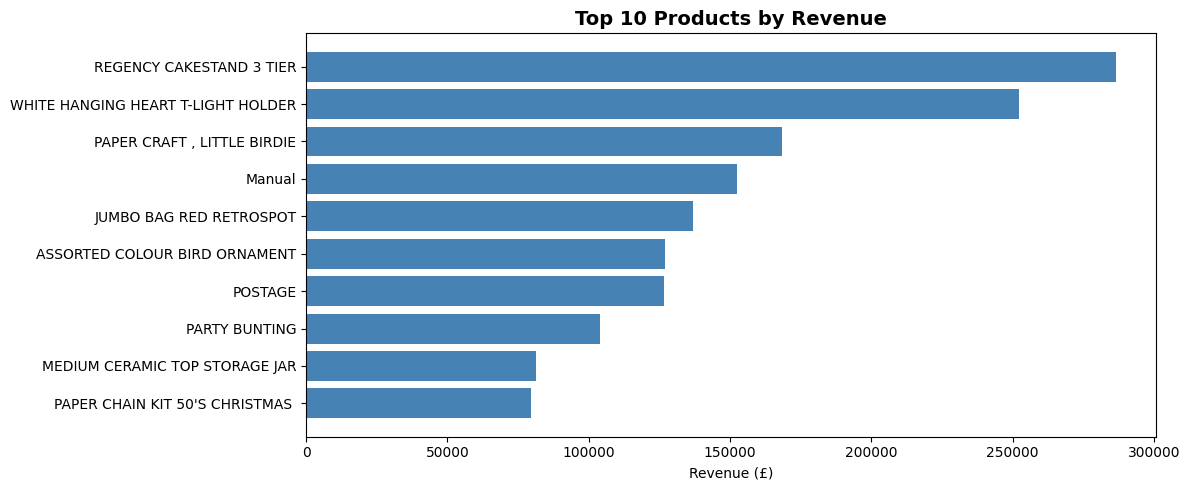


Top 10 Products:
                       Description   Revenue
          REGENCY CAKESTAND 3 TIER 286486.30
WHITE HANGING HEART T-LIGHT HOLDER 252072.46
       PAPER CRAFT , LITTLE BIRDIE 168469.60
                            Manual 152340.57
           JUMBO BAG RED RETROSPOT 136980.08
     ASSORTED COLOUR BIRD ORNAMENT 127074.17
                           POSTAGE 126563.04
                     PARTY BUNTING 103880.23
    MEDIUM CERAMIC TOP STORAGE JAR  81416.73
   PAPER CHAIN KIT 50'S CHRISTMAS   79594.33


In [35]:
# Group by description and sum revenue
top_products = df.groupby('Description')['Revenue'].sum().reset_index()
top_products = top_products.sort_values('Revenue', ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.barh(top_products['Description'], top_products['Revenue'], color='steelblue')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.savefig('../data/top_products.png', dpi=150)
plt.show()

print("\nTop 10 Products:")
print(top_products[['Description', 'Revenue']].to_string(index=False))

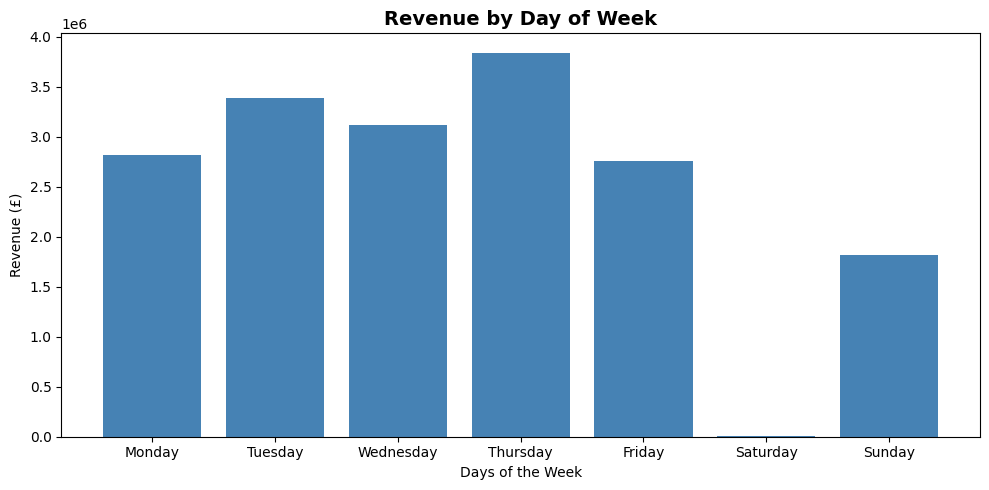


Revenue by Day:
DayOfWeek    Revenue
   Monday 2817407.81
  Tuesday 3384678.83
Wednesday 3115619.69
 Thursday 3841082.96
   Friday 2758423.49
 Saturday    9803.05
   Sunday 1816413.34


In [36]:
# Extract day of week
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

# Define correct order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_revenue = df.groupby('DayOfWeek')['Revenue'].sum().round(2).reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))
plt.bar(day_revenue['DayOfWeek'], day_revenue['Revenue'], color='steelblue')
plt.title('Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Days of the Week')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../data/revenue_by_day.png', dpi=150)
plt.show()

print("\nRevenue by Day:")
print(day_revenue.to_string(index=False))

In [37]:


# Verify clean columns
print("Columns now:", df.columns.tolist())
print("Total columns:", len(df.columns))

Columns now: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'MonthYear', 'DayOfWeek', 'YearMonth']
Total columns: 12


In [40]:
# Drop the duplicate and misspelled columns
df = df.drop(columns=['MonthYear'])

# Verify clean columns
print("Columns now:", df.columns.tolist())
print("Total columns:", len(df.columns))

Columns now: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'DayOfWeek', 'YearMonth']
Total columns: 11


In [48]:
# Save clean data to CSV 
df.to_csv('../data/online_retail_cleaned.csv', index=False)
print("Clean data saved successfully!")
print(f"File saved with {len(df):,} rows and {len(df.columns)} columns")
print(f"Columns: {df.columns.tolist()}")

Clean data saved successfully!
File saved with 805,549 rows and 11 columns
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'DayOfWeek', 'YearMonth']
